# first kind of dump notebook to get back into processing model stuff

In [1]:
import xarray as xr 
import pandas as pd
import numpy as np 
from glob import glob 
import matplotlib.pyplot as plt 
from scipy.special import gamma, gammainc
import re
import os
import imageio

import sys
# needed so I can call the functions from another folder.
sys.path.append('/home/users/esree/shes_a_model/model_functions/')
# loads of homemade functions <3 <3
from casim_boring_functions import open_declan_nc, make_variable, slice_to_domain, mask_altitude


# v1 of code

In [ ]:
## unrisk bits
data_path = '/gws/ssde/j25a/unrisk/workshop_fieldcampaigns/Materials/'

ds_model = xr.open_mfdataset(data_path+"model/20220731T0000Z_LMagda_km1p5set1_expt1_pz01*.nc", decode_timedelta=True)
ds_model_orog = xr.open_dataset(data_path+"model/20220716T0000Z_LMagda_km1p5set1_expt1_pa000_model_orog_rgd.nc")
## calculate the true height
true_level_height_asl = ds_model['level_height'] + ds_model['sigma'] *  ds_model_orog['surface_altitude']
## add as dataset coordinate
ds_model = ds_model.assign_coords(true_level_height_asl=true_level_height_asl)

In [3]:
## we will be using declan's model runs, which i belive live here:
model_run_loc = '/gws/ssde/j25a/dcmex/users/dfinney/data/CASIM/dd455_4apr2024_ncs_27feb2025v2'
day = '20220730T0000Z'
experiment = 'expt1' # there is a couple dec has ran (i forgot the details of each of them) - i think 1 = normal one

## orog file in different location - as has been re-gridded, and is saved as new nc
## i have pinched the one from unrisk
orog_loc = '/gws/ssde/j25a/dcmex/users/ezriab/modelling/20220716T0000Z_LMagda_km1p5set1_expt1_pa000_model_orog_rgd.nc'

hydro_nc_example = '20220730T0000Z_LMagda_km1p5set1_expt1_pz012.nc' # when no added ending = hydrometeors
density_nc_example = '20220730T0000Z_LMagda_km1p5set1_expt1_pz012_density.nc' # this is just density

a_nc_loc = f'{model_run_loc}/{day}/{experiment}/{density_nc_example}' 

In [4]:
# orography bits - so can assign true height
plain_model = xr.open_mfdataset(a_nc_loc, decode_timedelta=True)
orog_model = xr.open_mfdataset(orog_loc, decode_timedelta=True)
true_level_height_asl = plain_model['level_height'] + plain_model['sigma'] *  orog_model['surface_altitude']


In [5]:
## open up all the hydro + density files - combine into 1
file_pattern = glob(f'{model_run_loc}/{day}/{experiment}/{day}_LMagda_km1p5set1_{experiment}_pz*.nc')
# ^^ gives all files, too many files - don't need all

# removing the latest files vv
filtered_files = [f for f in file_pattern if int(re.search(r'_pz(\d+)', f).group(1)) < 21]

hydro_files = sorted(f for f in filtered_files if "_density" not in f and "_w" not in f)
density_files = sorted(f for f in filtered_files if "_density" in f)

# open up + stack on time
all_hydro = xr.open_mfdataset(hydro_files, decode_timedelta=True, combine='nested', concat_dim='time')
all_density = xr.open_mfdataset(density_files, decode_timedelta=True, combine='nested',concat_dim='time')

# density is output by the model on slightly different times, 
# because air density is fairly constant, we can assume the closest times of each variable match. 
all_density = all_density.assign_coords(time=all_hydro.time)
combined = xr.merge([all_hydro, all_density], compat='no_conflicts')

# add in asl height
combined = combined.assign_coords(true_level_height_asl=true_level_height_asl)


In [6]:
# model subdomain of interest:
min_gridlat = -0.15
max_gridlat = 0.14
min_gridlon = 359.93
max_gridlon = 360.11

# slice so we only look at smaller domain - where aircraft pass
combined_subdomain = combined.sel(grid_longitude=slice(min_gridlon, max_gridlon), grid_latitude=slice(min_gridlat, max_gridlat))

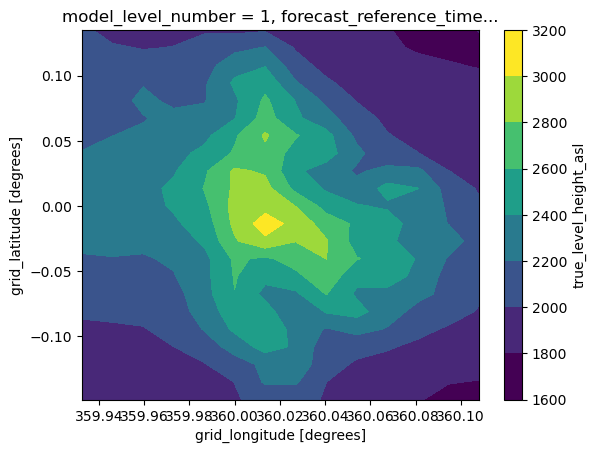

In [7]:
#one_time = combined_subdomain.sel(time = '2022-07-30T12:15:00.000000000')
combined_subdomain['true_level_height_asl'][0].plot.contourf()

# how to slice

#### using the original dimensions

In [7]:
## okay, so we have our data all combined into combined_subdomain

## we have 4 dimensions: time: 36, model_level_number: 70,  grid_longitude: 22, grid_latitude: 14
## i.e. 36 time steps, 70 vertical levels, and a grid of 22x14 in the horizontal

##### using the normal dimensions:
# e.g. we want to select a single point in this grid + time
one_datapoint = combined_subdomain["number_of_cloud_droplets_per_kg_of_air"].isel(
    time=0,
    model_level_number=0,
    grid_latitude=10,
    grid_longitude=5)

# e.g. we want a horizontal slice at a given time and level
### (grid_latitude, grid_longitude) dimensions
horizontal_slice = combined_subdomain["number_of_cloud_droplets_per_kg_of_air"].isel(
    time=0,
    model_level_number=0)


# e.g. we want a vertical slice at given time and lat/lon
### (model_level_number,) dimensions
vertical_slice = combined_subdomain["number_of_cloud_droplets_per_kg_of_air"].isel(
    time=0,
    grid_latitude=10,
    grid_longitude=5)


#### so using .sel() to select by coordinate value
a_time = combined_subdomain.sel(time="2022-07-30T15:30:00.000000000")
level_slice = combined_subdomain.sel(model_level_number=10)


#### for generic slicing of index, we use .isel() with slice
first_5_timesteps = combined_subdomain.isel(time=slice(0, 5))
first_20_levels = combined_subdomain.isel(model_level_number=slice(0, 20))

# smaller subdomain - zoom in (but tbf, difficult to interpret slicing)
subset_horizontal = combined_subdomain.isel(grid_latitude=slice(5, 15),grid_longitude=slice(3, 10))


######### conditional slicing - physical constraints
## e.g. only keep cloudy cells
cloudy = combined_subdomain.where(combined_subdomain["cloud_volume_fraction_in_atmosphere_layer"] >= 1)

#### using lat / lon / true_level_height_asl to slice with
these are **not** dimensions, but auxiliary coordinates, so need to use .where() instead

In [8]:
###### true_level_height_asl
## e.g. only above 2250m -
#  all dimensions remain, but values that don't meet the condition are masked out 
#  (i.e. everything less than 2250m is set to NaN)
above_2250m = da = combined_subdomain.where(combined_subdomain["true_level_height_asl"] > 2250)

# e.g. between near 2250m(+/- 50m) (this is quite cool)
subset = combined_subdomain.where(abs(combined_subdomain["true_level_height_asl"] - 2250) < 50)


#### slice by latitude (// same thing with longitude)
## as lat is coord, with dimensions (grid_latitude, grid_longitude)
lat_select = combined_subdomain.where(combined_subdomain["lat"] > 34)

## or a band of latitude
lat_band_subset = combined_subdomain.where((combined_subdomain["lat"] > 33.9) & (combined_subdomain["lat"] < 34.1))

#### combination of lat / lon slicing
lat_lon_subset = combined_subdomain.where(
    (combined_subdomain["lat"] > 33.9) & 
    (combined_subdomain["lat"] < 34.1) & 
    (combined_subdomain["lon"] > -107.3) & 
    (combined_subdomain["lon"] < -107.1))

# other

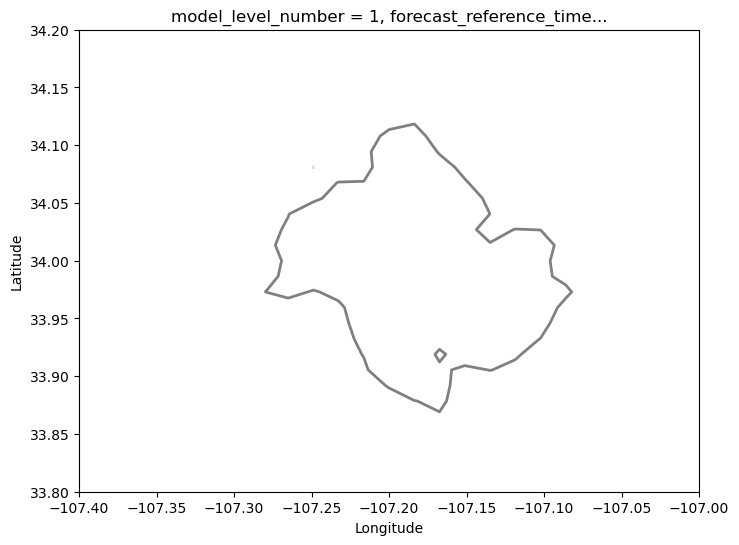

In [9]:

fig, ax = plt.subplots(figsize=(8,6))
'''
combined_subdomain["true_level_height_asl"].isel(model_level_number=0).plot(
    x="lon",
    y="lat",
    ax=ax,
    cmap="viridis")
'''
combined_subdomain["true_level_height_asl"].isel(
    model_level_number=0).plot.contour(
    x="lon",
    y="lat",
    levels=[2250],   # only this contour
    colors="grey",
    linewidths=2,
    ax=ax)

# set same min / max lat lons as radar plots - easily compare
ax.set_xlim(-107.4, -107.0)   # longitudes
ax.set_ylim(33.8, 34.2)      # latitudes

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

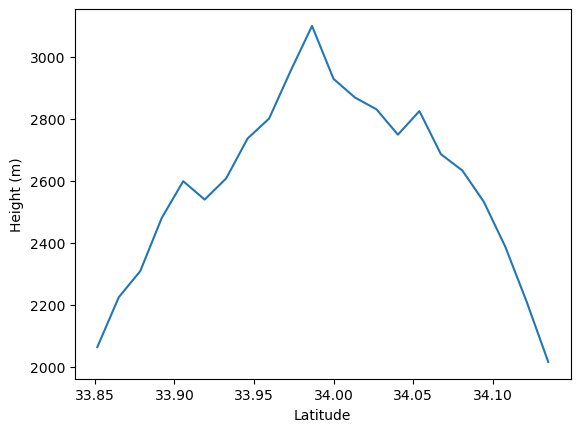

In [10]:
# for our domain, i would like a contour line of the max altiude of the topography - 
#   i.e. the max height of true_level_height_asl variable at model_level_number=0 (the surface level)
# which i would like it looking along latitude and longitude dimensions

# so getting the highest altitude of the surface, need to select lowest model level number from true_level_height_asl
# (this is basically the orography)
orography = combined_subdomain["true_level_height_asl"].isel(model_level_number=0)

# then for each grid lat / lon, we choose the max height
max_height_lat = orography.max(dim="grid_latitude") # function of longitude
max_height_lon = orography.max(dim="grid_longitude") # fuction of latitude

## as lat and lon are 2D (bcos model grid lat lon is rotated)
## this is done to flatten out lat / lon dimensions
lon_1d = combined_subdomain["lon"].mean(dim="grid_latitude")
lat_1d = combined_subdomain["lat"].mean(dim="grid_longitude")
'''
plt.plot(
    lon_1d,
    max_height_lat)

plt.xlabel("Longitude")
plt.ylabel("Height (m)")
plt.show()
'''

plt.plot(
    lat_1d,
    max_height_lon)

plt.xlabel("Latitude")
plt.ylabel("Height (m)")
plt.show()

In [12]:
lon_1d.values

array([-107.28143964, -107.26515698, -107.24887432, -107.23259166,
       -107.216309  , -107.20002633, -107.18374367, -107.167461  ,
       -107.15117834, -107.13489568, -107.11861302, -107.10233037,
       -107.08604772, -107.06976508])

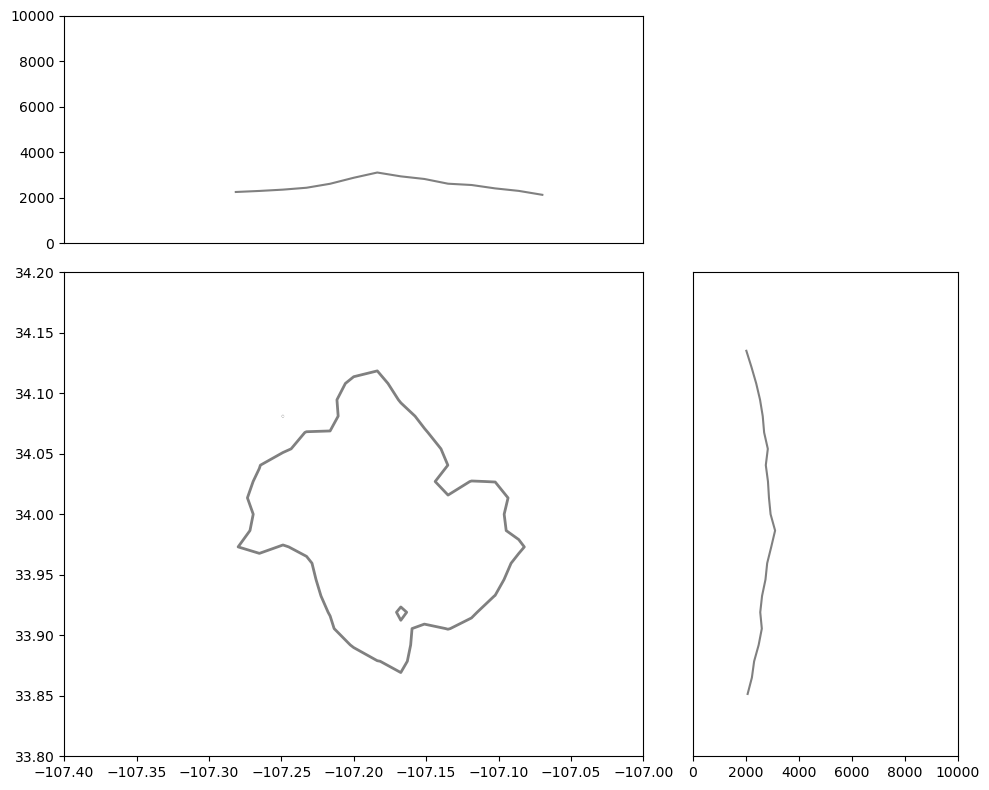

In [13]:

min_lat = 34.2
max_lat = 33.8
min_lon = -107.4
max_lon = -107.0

fig = plt.figure(figsize=(10, 8))

# Create a 3x3 logical grid
gs = fig.add_gridspec(3, 3)

# Subplots with custom spans:
ax1 = fig.add_subplot(gs[0, 0:2])   # top-left → 2 cols × 1 row
ax2 = fig.add_subplot(gs[0, 2])     # top-right → 1 col × 1 row
ax2.axis("off")
ax3 = fig.add_subplot(gs[1:3, 0:2]) # bottom-left → 2 cols × 2 rows
ax4 = fig.add_subplot(gs[1:3, 2])   # bottom-right → 1 col × 2 rows

ax1.plot(lon_1d, max_height_lat, color="grey")
ax1.set_xlim(min_lon, max_lon)
ax1.set_ylim(0,10000)
ax1.tick_params(axis="x", bottom=False, labelbottom=False) # turn off y-axis ticks and labels for ax4

ax4.plot(max_height_lon, lat_1d, color="grey")
ax4.set_ylim(max_lat, min_lat)
ax4.set_xlim(0,10000)
ax4.tick_params(axis="y", left=False, labelleft=False) # turn off y-axis ticks and labels for ax4

ax3.set_xlim(min_lon, max_lon)
ax3.set_ylim(max_lat, min_lat)
'''
## main plot 
combined_subdomain["true_level_height_asl"].isel(model_level_number=0).plot.contour(
    x="lon",
    y="lat",
    levels=[2250],   # only this contour
    colors="grey",
    linewidths=2,
    ax=ax3)
'''

ax3.contour(
    combined_subdomain["lon"].values,
    combined_subdomain["lat"].values,
    orography.values,
    levels=[2250],   # only this contour
    colors="grey",
    linewidths=2)

plt.tight_layout()
plt.show()

In [14]:
# use one time for now and have a look
one_time = combined_subdomain.sel(time = '2022-07-30T17:00:00.000000000') # this is where lot of graupel starting to form
one_time_column = one_time.sum(dim=["grid_latitude", "grid_longitude"], skipna=True)
one_time_flattened_column = one_time.sum(dim = ['model_level_number'], skipna=True)

# making plots that are useful?

In [ ]:
a_date = '20220730'
a_experiment = 'expt1'

new_combined = open_declan_nc(a_date, a_experiment)
sliced_domain = slice_to_domain(new_combined)

## make new units for some hydrometeors
new_hydro_list = ['graupel', 'cloud', 'ice', 'snow', 'rain']
for hydro in new_hydro_list:
    sliced_domain = make_variable(sliced_domain, hydro)

### vertical distribution?

In [51]:
combined_subdomain

<xarray.Dataset> Size: 59MB
Dimensions:                                           (time: 36,
                                                       model_level_number: 70,
                                                       grid_latitude: 22,
                                                       grid_longitude: 14)
Coordinates:
  * time                                              (time) datetime64[ns] 288B ...
  * model_level_number                                (model_level_number) int32 280B ...
  * grid_latitude                                     (grid_latitude) float32 88B ...
  * grid_longitude                                    (grid_longitude) float64 112B ...
    forecast_reference_time                           datetime64[ns] 8B ...
    forecast_period                                   timedelta64[ns] 8B ...
    level_height                                      (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    sigma                                             (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    lon                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    lat                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    true_level_height_asl                             (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(70, 22, 14), meta=np.ndarray>
Data variables: (12/19)
    number_of_cloud_droplets_per_kg_of_air            (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_rain_drops_per_kg_of_air                (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_ice_particles_per_kg_of_air             (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_snow_aggregates_per_kg_of_air           (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_graupel_particles_per_kg_of_air         (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    cloud_volume_fraction_in_atmosphere_layer         (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    ...                                                ...
    mass_fraction_of_graupel_in_air                   (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    mass_fraction_of_rain_in_air                      (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    specific_humidity                                 (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    Density used for rad layers (kg m-3)              (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    graupel_number_m3                                 (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    graupel_mass_m3                                   (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
Attributes: (12/14)
    um_suite:          u-dd455@281404
    casim_branches:    https://code.metoffice.gov.uk/trac/monc/browser/casim/...
    um_branches:       https://code.metoffice.gov.uk/trac/um/browser/main/bra

In [13]:
## vertical profile across whole domain?
# we do plot of mean + SD?

""" ~ ~ ~ ~ ~ ~ ~ ~ ~ graupel mess ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~"""
combined_subdomain['graupel_number_m3'] = combined_subdomain['number_of_graupel_particles_per_kg_of_air'] * combined_subdomain['Density used for rad layers (kg m-3)']
combined_subdomain["graupel_number_m3"].attrs["units"] = "m-3"
combined_subdomain["graupel_number_m3"].attrs["long_name"] = "Graupel number concentration"

combined_subdomain['graupel_mass_m3'] = combined_subdomain['mass_fraction_of_graupel_in_air'] * combined_subdomain['Density used for rad layers (kg m-3)']
combined_subdomain["graupel_mass_m3"].attrs["units"] = "kg m-3"
combined_subdomain["graupel_mass_m3"].attrs["long_name"] = "Graupel mass concentration"

## do it per L too - usual units
combined_subdomain['graupel_number_L'] = combined_subdomain["graupel_number_m3"] * 1e-3
combined_subdomain["graupel_number_L"].attrs["units"] = "L-1"
combined_subdomain["graupel_number_L"].attrs["long_name"] = "Graupel number concentration (L-1)"

combined_subdomain['graupel_mass_L'] = combined_subdomain["graupel_mass_m3"] * 1e-3
combined_subdomain["graupel_mass_L"].attrs["units"] = "L-1"
combined_subdomain["graupel_mass_L"].attrs["long_name"] = "Graupel mass concentration (L-1)"


combined_subdomain['graupel_mass_L_g'] = combined_subdomain["graupel_mass_L"] * 1e3
combined_subdomain["graupel_mass_L_g"].attrs["units"] = "g L-1"
combined_subdomain["graupel_mass_L_g"].attrs["long_name"] = "Graupel mass concentration (g L-1)"


""" ~ ~ ~ ~ ~ ~ ~ ~ ~ cloud mess ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~"""
combined_subdomain['cloud_droplets_number_m3'] = combined_subdomain['number_of_cloud_droplets_per_kg_of_air'] * combined_subdomain['Density used for rad layers (kg m-3)']
combined_subdomain["cloud_droplets_number_m3"].attrs["units"] = "m-3"
combined_subdomain["cloud_droplets_number_m3"].attrs["long_name"] = "Cloud droplets number concentration"

combined_subdomain["cloud_droplets_number_cc"] = combined_subdomain["cloud_droplets_number_m3"] * 1e-6
combined_subdomain["cloud_droplets_number_cc"].attrs["units"] = "cm-3"
combined_subdomain["cloud_droplets_number_cc"].attrs["long_name"] = "Cloud droplets number concentration (cm-3)"

combined_subdomain['cloud_droplets_mass_m3'] = combined_subdomain['mass_fraction_of_cloud_liquid_water_in_air'] * combined_subdomain['Density used for rad layers (kg m-3)']
combined_subdomain["cloud_droplets_mass_m3"].attrs["units"] = "kg m-3"
combined_subdomain["cloud_droplets_mass_m3"].attrs["long_name"] = "Cloud droplets mass concentration"


""" ~ ~ ~ ~ ~ ~ ~ ~ ~ ice / snow / rain stuff ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~"""
# think will just do number conc
combined_subdomain['ice_number_m3'] = combined_subdomain['number_of_ice_particles_per_kg_of_air'] * combined_subdomain['Density used for rad layers (kg m-3)']
combined_subdomain["ice_number_m3"].attrs["units"] = "m-3"
combined_subdomain["ice_number_m3"].attrs["long_name"] = "Ice number concentration"
combined_subdomain['ice_number_L'] = combined_subdomain["ice_number_m3"] * 1e-3
combined_subdomain["ice_number_L"].attrs["units"] = "L-1"
combined_subdomain["ice_number_L"].attrs["long_name"] = "Ice number concentration (L-1)"

combined_subdomain['snow_number_m3'] = combined_subdomain['number_of_snow_aggregates_per_kg_of_air'] * combined_subdomain['Density used for rad layers (kg m-3)']
combined_subdomain["snow_number_m3"].attrs["units"] = "m-3"
combined_subdomain["snow_number_m3"].attrs["long_name"] = "Snow number concentration"
combined_subdomain['snow_number_L'] = combined_subdomain["snow_number_m3"] * 1e-3
combined_subdomain["snow_number_L"].attrs["units"] = "L-1"
combined_subdomain["snow_number_L"].attrs["long_name"] = "Snow number concentration (L-1)"

combined_subdomain['rain_number_m3'] = combined_subdomain['number_of_rain_drops_per_kg_of_air'] * combined_subdomain['Density used for rad layers (kg m-3)']
combined_subdomain["rain_number_m3"].attrs["units"] = "m-3"
combined_subdomain["rain_number_m3"].attrs["long_name"] = "Rain number concentration"
combined_subdomain['rain_number_L'] = combined_subdomain["rain_number_m3"] * 1e-3
combined_subdomain["rain_number_L"].attrs["units"] = "L-1"
combined_subdomain["rain_number_L"].attrs["long_name"] = "Rain number concentration (L-1)"


In [10]:
def make_variable(big_xr,
                  var_name,
                  number_or_mass = 'number',
                  m3 = True,
                  L = True,
                  density_name = 'Density used for rad layers (kg m-3)'):
    """
    function to make new variable for a given hydrometeor type, e.g. graupel, cloud droplets, ice, snow, rain
    This also converts units

    Args:
        big_xr (xarray dataset): the dataset to add the new variable to
        var_name (str): the hydrometeor type, e.g. 'graupel', 'cloud', 'ice', 'snow', 'rain'
        number_or_mass (str): whether to calculate number concentration or mass concentration, options are 'number' or 'mass'
        m3 (bool): whether to calculate concentration in m-3 (default True)
        L (bool): whether to calculate concentration in L-1 (default True)
        density_name (str): the name of the density variable in big_xr to use for conversion (default 'Density used for rad layers (kg m-3)')

    Returns:
        big_xr (xarray dataset): the input dataset with the new variable(s) added
    """

    # 
    if number_or_mass == 'number':
        var_dict = {'graupel': 'number_of_graupel_particles_per_kg_of_air',
                    'cloud' : 'number_of_cloud_droplets_per_kg_of_air',
                    'ice' : 'number_of_ice_particles_per_kg_of_air',
                    'snow' : 'number_of_snow_aggregates_per_kg_of_air',
                    'rain' : 'number_of_rain_drops_per_kg_of_air'}
    else:
        # mass values
        var_dict = {'graupel': 'mass_fraction_of_graupel_in_air',
                    'cloud' : 'mass_fraction_of_cloud_liquid_water_in_air',
                    'ice' : 'mass_fraction_of_cloud_ice_in_air',
                    'snow' : 'mass_fraction_of_cloud_ice_crystals_in_air',
                    'rain' : 'mass_fraction_of_rain_in_air'}
    
    var_casim_name = var_dict[var_name]

    if m3:
        new_var_name = f'{var_name}_{number_or_mass}_m3'
        big_xr[new_var_name] = big_xr[var_casim_name] * big_xr[density_name]
        big_xr[new_var_name].attrs["units"] = "m-3"
        big_xr[new_var_name].attrs["long_name"] = f"{var_name} {number_or_mass} concentration (m-3)"

    if L:
        new_var_name_l = f'{var_name}_{number_or_mass}_L'
        big_xr[new_var_name_l] = big_xr[f'{var_name}_{number_or_mass}_m3'] * 1e-3
        big_xr[new_var_name_l].attrs["units"] = "L-1"
        big_xr[new_var_name_l].attrs["long_name"] = f"{var_name} {number_or_mass} concentration (L-1)"
    
    return big_xr


In [11]:
updated_combined_subdomain = make_variable(combined_subdomain, var_name='graupel', number_or_mass='number')

In [12]:
updated_combined_subdomain

<xarray.Dataset> Size: 59MB
Dimensions:                                           (time: 36,
                                                       model_level_number: 70,
                                                       grid_latitude: 22,
                                                       grid_longitude: 14)
Coordinates:
  * time                                              (time) datetime64[ns] 288B ...
  * model_level_number                                (model_level_number) int32 280B ...
  * grid_latitude                                     (grid_latitude) float32 88B ...
  * grid_longitude                                    (grid_longitude) float64 112B ...
    forecast_reference_time                           datetime64[ns] 8B ...
    forecast_period                                   timedelta64[ns] 8B ...
    level_height                                      (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    sigma                                             (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    lon                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    lat                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    true_level_height_asl                             (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(70, 22, 14), meta=np.ndarray>
Data variables: (12/19)
    number_of_cloud_droplets_per_kg_of_air            (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_rain_drops_per_kg_of_air                (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_ice_particles_per_kg_of_air             (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_snow_aggregates_per_kg_of_air           (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_graupel_particles_per_kg_of_air         (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    cloud_volume_fraction_in_atmosphere_layer         (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    ...                                                ...
    mass_fraction_of_graupel_in_air                   (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    mass_fraction_of_rain_in_air                      (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    specific_humidity                                 (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    Density used for rad layers (kg m-3)              (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    graupel_number_m3                                 (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    graupel_number_L                                  (time, model_level_number, grid_latitude, grid_longitude) float32 3MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
Attributes: (12/14)
    um_suite:          u-dd455@281404
    casim_branches:    https://code.metoffice.gov.uk/trac/monc/browser/casim/...
    um_branches:       https://code.metoffice.gov.uk/trac/um/browser/main/bra

In [17]:
if (combined_subdomain['graupel_number_m3'].values ==
    updated_combined_subdomain['graupel_number_m3'].values).all():
    print("it works!")

it works!


In [29]:
## make just column of air from over our domain
subdomain_column_max = combined_subdomain.max(dim=["grid_latitude", "grid_longitude"])
subdomain_column_mean = combined_subdomain.mean(dim=["grid_latitude", "grid_longitude"])

# as we lose the alt we create, make mean profile, used for plotting
height_profile = combined_subdomain["true_level_height_asl"].mean(dim=["grid_latitude", "grid_longitude"])
time_list = combined_subdomain["time"].values

reduced_time_list = time_list[10:-10]


In [30]:
subdomain_column_mean

<xarray.Dataset> Size: 314kB
Dimensions:                                           (time: 36,
                                                       model_level_number: 70)
Coordinates:
  * time                                              (time) datetime64[ns] 288B ...
  * model_level_number                                (model_level_number) int32 280B ...
    forecast_reference_time                           datetime64[ns] 8B ...
    forecast_period                                   timedelta64[ns] 8B ...
    level_height                                      (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    sigma                                             (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
Data variables: (12/31)
    number_of_cloud_droplets_per_kg_of_air            (time, model_level_number) float32 10kB dask.array<chunksize=(2, 35), meta=np.ndarray>
    number_of_rain_drops_per_kg_of_air                (time, model_level_number) float32 10kB dask.array<chunksize=(2, 35), meta=np.ndarray>
    number_of_ice_particles_per_kg_of_air             (time, model_level_number) float32 10kB dask.array<chunksize=(2, 35), meta=np.ndarray>
    number_of_snow_aggregates_per_kg_of_air           (time, model_level_number) float32 10kB dask.array<chunksize=(2, 35), meta=np.ndarray>
    number_of_graupel_particles_per_kg_of_air         (time, model_level_number) float32 10kB dask.array<chunksize=(2, 35), meta=np.ndarray>
    cloud_volume_fraction_in_atmosphere_layer         (time, model_level_number) float32 10kB dask.array<chunksize=(2, 35), meta=np.ndarray>
    ...                                                ...
    ice_number_m3                                     (time, model_level_number) float32 10kB dask.array<chunksize=(2, 35), meta=np.ndarray>
    ice_number_L                                      (time, model_level_number) float32 10kB dask.array<chunksize=(2, 35), meta=np.ndarray>
    snow_number_m3                                    (time, model_level_number) float32 10kB dask.array<chunksize=(2, 35), meta=np.ndarray>
    snow_number_L                                     (time, model_level_number) float32 10kB dask.array<chunksize=(2, 35), meta=np.ndarray>
    rain_number_m3                                    (time, model_level_number) float32 10kB dask.array<chunksize=(2, 35), meta=np.ndarray>
    rain_number_L                                     (time, model_level_number) float32 10kB dask.array<chunksize=(2, 35), meta=np.ndarray>

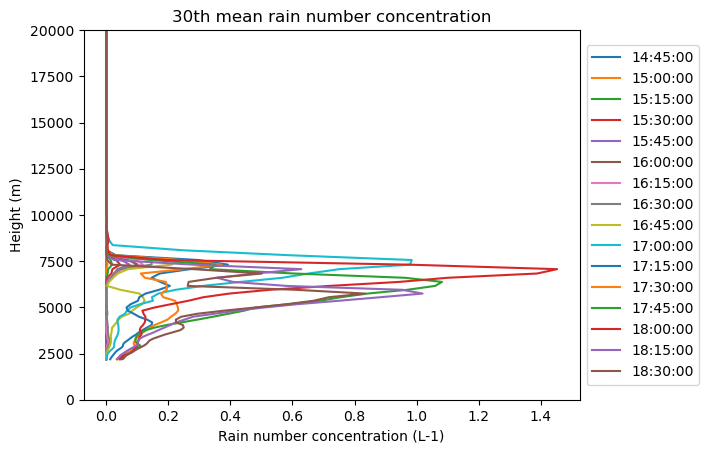

In [35]:
for t in reduced_time_list:
    a_time = subdomain_column_mean.sel(time=t)
    time_name = pd.to_datetime(str(t)).strftime("%H:%M:%S")
    plt.plot(a_time['rain_number_L'].values, height_profile, label=time_name)

plt.ylim(0,20000)
plt.ylabel("Height (m)")
plt.xlabel("Rain number concentration (L-1)")
#plt.xscale("log")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.title('30th mean rain number concentration')

plt.show()


#### next things to do:
* time series of concentration
* make gif of cloud development from 3 perspectives - birds eye, lat / lon
    * would this need to be max values - kind of like reflectivity
* when does cloud form ? when do we see graupel? 

In [17]:
subdomain_domain_max = combined_subdomain.max(dim=["grid_latitude", "grid_longitude", "model_level_number"])
subdomain_domain_mean = combined_subdomain.mean(dim=["grid_latitude", "grid_longitude", "model_level_number"])


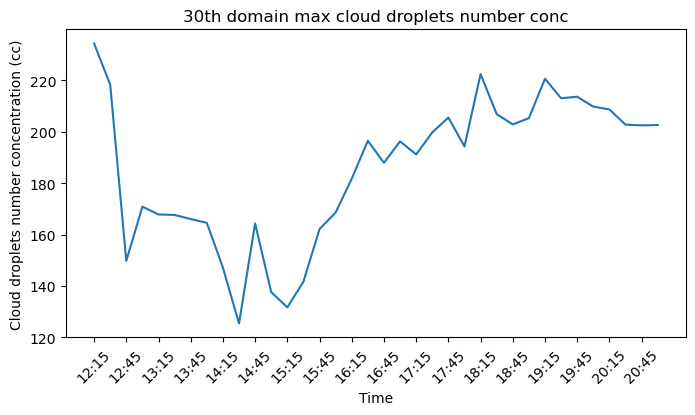

In [26]:
### time series of concentration 
## domain max? 
just_time = [str(t)[11:16] for t in subdomain_domain_max['time'].values]

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(just_time, subdomain_domain_max['cloud_droplets_number_cc'].values)
ax.set_xticks(ax.get_xticks()[::2])   # keep every 2nd tick
ax.set_xticklabels(just_time[::2], rotation=45)
ax.set_title('30th domain max cloud droplets number conc')
ax.set_ylabel("Cloud droplets number concentration (cc)")
ax.set_xlabel("Time")
plt.show()


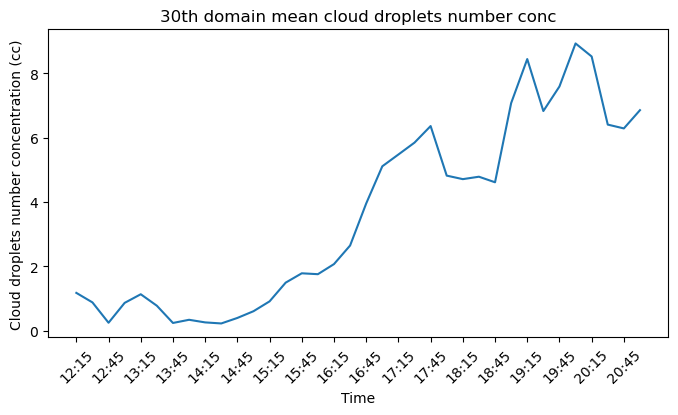

In [28]:
## domain mean? 
just_time = [str(t)[11:16] for t in subdomain_domain_mean['time'].values]

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(just_time, subdomain_domain_mean['cloud_droplets_number_cc'].values)
ax.set_xticks(ax.get_xticks()[::2])   # keep every 2nd tick
ax.set_xticklabels(just_time[::2], rotation=45)
ax.set_title('30th domain mean cloud droplets number conc')
ax.set_ylabel("Cloud droplets number concentration (cc)")
ax.set_xlabel("Time")
plt.show()

#### gif?

In [56]:
t = '2022-07-30T18:15:00.000000000'
a_time = combined_subdomain.sel(time=t)
#a_time#['number_of_cloud_droplets_per_kg_of_air'])
'''
alt_lon = combined_subdomain['true_level_height_asl'].mean(dim=['grid_longitude'])
alt_lat = combined_subdomain['true_level_height_asl'].mean(dim=['grid_latitude'])
lat_max = a_time.max(dim='grid_latitude')
lon_max = a_time.max(dim='grid_longitude')
'''

"\nalt_lon = combined_subdomain['true_level_height_asl'].mean(dim=['grid_longitude'])\nalt_lat = combined_subdomain['true_level_height_asl'].mean(dim=['grid_latitude'])\nlat_max = a_time.max(dim='grid_latitude')\nlon_max = a_time.max(dim='grid_longitude')\n"

In [57]:
orography = combined_subdomain["true_level_height_asl"].isel(model_level_number=0)

# then for each grid lat / lon, we choose the max height
max_height_lat = orography.max(dim="grid_latitude") # function of longitude
max_height_lon = orography.max(dim="grid_longitude") # fuction of latitude

## as lat and lon are 2D (bcos model grid lat lon is rotated)
## this is done to flatten out lat / lon dimensions
lon_1d = combined_subdomain["lon"].mean(dim="grid_latitude") #(grid_longitude,)
lat_1d = combined_subdomain["lat"].mean(dim="grid_longitude") #(grid_latitude,)

In [58]:
### do lon vs alt plot
cloud_var = 'cloud_droplets_number_cc'

# max over latitude (model lat) - for all variables
lat_max = a_time[cloud_var].max(dim="grid_latitude") # (model_level_number, grid_longitude)
# max lat - specifically for altitude
z_lat_max = a_time["true_level_height_asl"].max(dim="grid_latitude") # (model_level_number, grid_longitude)

lon_max = a_time[cloud_var].max(dim="grid_longitude") # (model_level_number, grid_latitude)
z_lon_max = a_time["true_level_height_asl"].max(dim="grid_longitude") # (model_level_number, grid_latitude)

z_max = a_time[cloud_var].max(dim="model_level_number") # (grid_latitude, grid_longitude)


z = lat_max.values 
h = z_lat_max.values 
lon = lon_1d.values

In [53]:
lat_max.values.max()

np.float32(202.62074)

/tmp/ipykernel_960320/1221300726.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


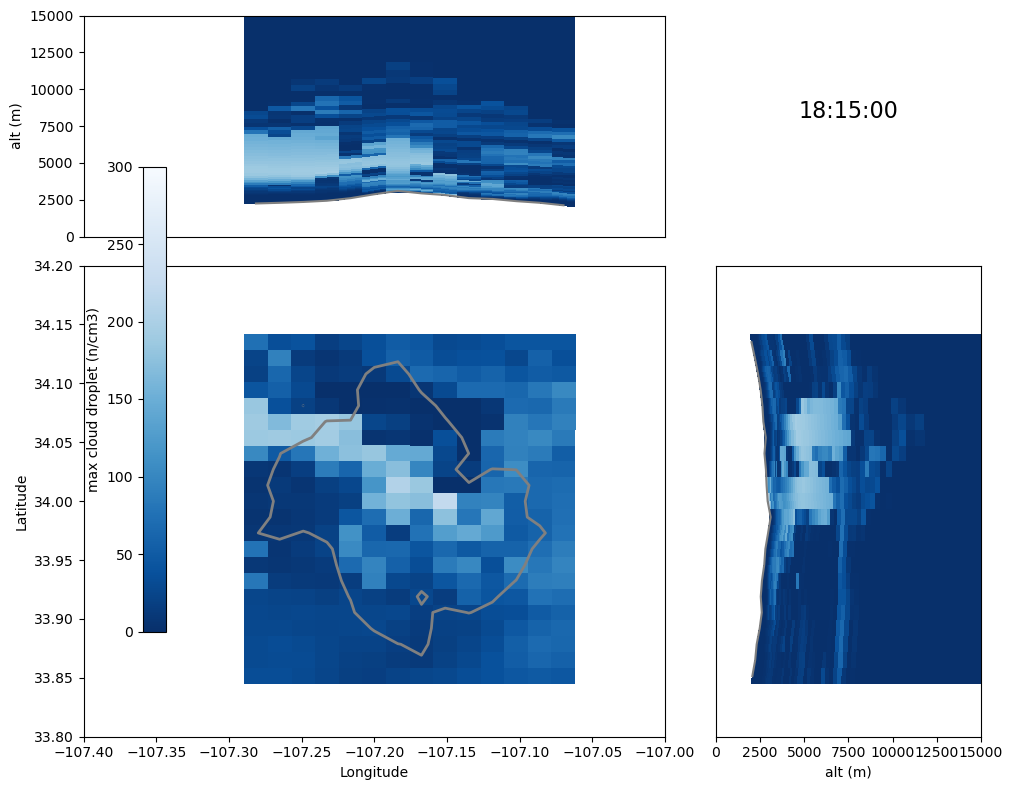

In [62]:


""" ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ """
# longitude plot - need max along latitude dimension

""" ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ """
vmax_n = 300
min_lat = 34.2
max_lat = 33.8
min_lon = -107.4
max_lon = -107.0

m_height_lim = 15000

fig = plt.figure(figsize=(10, 8))

# Create a 3x3 logical grid
gs = fig.add_gridspec(3, 3)

# Subplots with custom spans:
ax1 = fig.add_subplot(gs[0, 0:2])   # top-left → 2 cols × 1 row
ax2 = fig.add_subplot(gs[0, 2])     # top-right → 1 col × 1 row
ax2.axis("off")
ax3 = fig.add_subplot(gs[1:3, 0:2]) # bottom-left → 2 cols × 2 rows
ax4 = fig.add_subplot(gs[1:3, 2])   # bottom-right → 1 col × 2 rows

ax1.plot(lon_1d, max_height_lat, color="grey")
ax1.set_xlim(min_lon, max_lon)

# the pcm -> for making colourbar
ax1.pcolormesh(
    lon_1d.values,
    z_lat_max.values,
    lat_max.values,
    shading="auto",
    cmap="Blues_r",
    vmin=0, vmax=vmax_n)
ax1.set_ylabel("alt (m)")
ax1.set_ylim(0, m_height_lim)
ax1.tick_params(axis="x", bottom=False, labelbottom=False) # turn off y-axis ticks and labels for ax4

ax4.plot(max_height_lon, lat_1d, color="grey")
ax4.set_ylim(max_lat, min_lat)
ax4.pcolormesh(
    z_lon_max.T,
    lat_1d,
    lon_max.T,
    shading="auto",
    cmap="Blues_r",
    vmin=0, vmax=vmax_n)
ax4.set_xlabel("alt (m)")
ax4.set_xlim(0, m_height_lim)
ax4.tick_params(axis="y", left=False, labelleft=False) # turn off y-axis ticks and labels for ax4

ax3.set_xlim(min_lon, max_lon)
ax3.set_ylim(max_lat, min_lat)

ax3.contour(
    combined_subdomain["lon"].values,
    combined_subdomain["lat"].values,
    orography.values,
    levels=[2250],   # only this contour
    colors="grey",
    linewidths=2)

pcm = ax3.pcolormesh(
    a_time["lon"].values,
    a_time["lat"].values,
    z_max.values,
    shading="auto",
    cmap="Blues_r",
    vmin=0, vmax=vmax_n)

ax3.set_xlabel("Longitude")
ax3.set_ylabel("Latitude")

### add colourbar

cbar = fig.colorbar(
    pcm,
    ax=[ax1, ax3, ax4],
    orientation="vertical",
    location="left",
    pad=-0.0001,
    fraction=0.03)
cbar.set_label("max cloud droplet (n/cm3)")

## set time 
time_name = pd.to_datetime(str(t)).strftime("%H:%M:%S")

ax2.set_title(time_name, loc="center", y=0.5, fontsize=16)

plt.tight_layout()
plt.show()

#### make individual plots -> form into gif

In [ ]:
save_folder = '/home/users/esree/shes_a_model/dcmex_plotting/plot_saving/lat_lon_birdseye/'

time_list = combined_subdomain["time"].values

var_name = 'cloud_droplets_number_cc'

orography = combined_subdomain["true_level_height_asl"].isel(model_level_number=0)

# then for each grid lat / lon, we choose the max height
max_height_lat = orography.max(dim="grid_latitude") # function of longitude
max_height_lon = orography.max(dim="grid_longitude") # fuction of latitude

## as lat and lon are 2D (bcos model grid lat lon is rotated)
## this is done to flatten out lat / lon dimensions
lon_1d = combined_subdomain["lon"].mean(dim="grid_latitude") #(grid_longitude,)
lat_1d = combined_subdomain["lat"].mean(dim="grid_longitude") #(grid_latitude,)

min_lat = 34.2
max_lat = 33.8
min_lon = -107.4
max_lon = -107.0

vmax_n = 300
m_height_lim = 15000


for t in time_list:
    a_time = combined_subdomain.sel(time=t)
    save_name = f"{pd.to_datetime(str(t)).strftime('%y%m%d_%H%M%S')}_{var_name}"
    
    lat_max = a_time[cloud_var].max(dim="grid_latitude") # (model_level_number, grid_longitude)
    z_lat_max = a_time["true_level_height_asl"].max(dim="grid_latitude") # (model_level_number, grid_longitude)
    lon_max = a_time[cloud_var].max(dim="grid_longitude") # (model_level_number, grid_latitude)
    z_lon_max = a_time["true_level_height_asl"].max(dim="grid_longitude") # (model_level_number, grid_latitude)
    z_max = a_time[cloud_var].max(dim="model_level_number") # (grid_latitude, grid_longitude)

    z = lat_max.values 
    h = z_lat_max.values 
    lon = lon_1d.values

    """ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ plotting ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ """
    fig = plt.figure(figsize=(10, 8))

    # Create a 3x3 logical grid
    gs = fig.add_gridspec(3, 3)

    # Subplots with custom spans:
    ax1 = fig.add_subplot(gs[0, 0:2])   # top-left → 2 cols × 1 row
    ax2 = fig.add_subplot(gs[0, 2])     # top-right → 1 col × 1 row
    ax2.axis("off")
    ax3 = fig.add_subplot(gs[1:3, 0:2]) # bottom-left → 2 cols × 2 rows
    ax4 = fig.add_subplot(gs[1:3, 2])   # bottom-right → 1 col × 2 rows

    ax1.plot(lon_1d, max_height_lat, color="grey")
    ax1.set_xlim(min_lon, max_lon)

    # the pcm -> for making colourbar
    ax1.pcolormesh(
        lon_1d.values,
        z_lat_max.values,
        lat_max.values,
        shading="auto",
        cmap="Blues_r",
        vmin=0, vmax=vmax_n)
    ax1.set_ylabel("alt (m)")
    ax1.set_ylim(0, m_height_lim)
    ax1.tick_params(axis="x", bottom=False, labelbottom=False) # turn off y-axis ticks and labels for ax4

    ax4.plot(max_height_lon, lat_1d, color="grey")
    ax4.set_ylim(max_lat, min_lat)
    ax4.pcolormesh(
        z_lon_max.T,
        lat_1d,
        lon_max.T,
        shading="auto",
        cmap="Blues_r",
        vmin=0, vmax=vmax_n)
    ax4.set_xlabel("alt (m)")
    ax4.set_xlim(0, m_height_lim)
    ax4.tick_params(axis="y", left=False, labelleft=False) # turn off y-axis ticks and labels for ax4

    ax3.set_xlim(min_lon, max_lon)
    ax3.set_ylim(max_lat, min_lat)

    ax3.contour(
        combined_subdomain["lon"].values,
        combined_subdomain["lat"].values,
        orography.values,
        levels=[2250],   # only this contour
        colors="grey",
        linewidths=2)

    pcm = ax3.pcolormesh(
        a_time["lon"].values,
        a_time["lat"].values,
        z_max.values,
        shading="auto",
        cmap="Blues_r",
        vmin=0, vmax=vmax_n)

    ax3.set_xlabel("Longitude")
    ax3.set_ylabel("Latitude")

    ### add colourbar

    cbar = fig.colorbar(
        pcm,
        ax=[ax1, ax3, ax4],
        orientation="vertical",
        location="left",
        pad=-0.0001,
        fraction=0.03)
    cbar.set_label("max cloud droplet (n/cm3)")

    ## set time 
    time_name = pd.to_datetime(str(t)).strftime("%H:%M:%S")

    ax2.set_title(time_name, loc="center", y=0.5, fontsize=16)

    plt.tight_layout()
    plt.savefig(save_folder+save_name, bbox_inches='tight')
    plt.close()


/tmp/ipykernel_960320/2876787216.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_960320/2876787216.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_960320/2876787216.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_960320/2876787216.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_960320/2876787216.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_960320/2876787216.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so

In [64]:
save_folder = '/home/users/esree/shes_a_model/dcmex_plotting/plot_saving/lat_lon_birdseye/'

image_list = glob(os.path.join(save_folder, '*.png'))
image_list.sort()
frames = []
for i in range(len(image_list)):
    image = imageio.v2.imread(image_list[i])
    frames.append(image)

imageio.mimsave(save_folder+f'220730_{var_name}.gif', frames, fps=5)


## conc histogram

In [2]:
# this will need to be through time?

a_date = '20220730'
a_experiment = 'expt1'

new_combined = open_declan_nc(a_date, a_experiment, max_time = None)
sliced_domain = slice_to_domain(new_combined)

## make new units for some hydrometeors
new_hydro_list = ['graupel', 'cloud', 'ice', 'snow', 'rain']
for hydro in new_hydro_list:
    sliced_domain = make_variable(sliced_domain, hydro)

for hydro in new_hydro_list:
    sliced_domain = make_variable(sliced_domain, hydro, 'mass')


/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:450: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 9.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (100, 100).
  result_vars[name] = func(*variable_args)
/home/users/esree/miniforge3/envs/vs_code_envi/lib/python3.13/site-packages/dask/array/routines.py:333: PerformanceWarning: Increasing number of chunks by factor of 20
  intermediate = blockwise(


In [3]:
#sliced_domain['graupel_mass_L'].max().values
sliced_domain['graupel_mass_g_L'] = sliced_domain['graupel_mass_L'] * 1e3
sliced_domain['graupel_mass_g_L'].max().values

array(0.00149245, dtype=float32)

In [6]:
sliced_domain

<xarray.Dataset> Size: 167MB
Dimensions:                                           (time: 51,
                                                       model_level_number: 70,
                                                       grid_latitude: 22,
                                                       grid_longitude: 14)
Coordinates:
  * time                                              (time) datetime64[ns] 408B ...
  * model_level_number                                (model_level_number) int32 280B ...
  * grid_latitude                                     (grid_latitude) float32 88B ...
  * grid_longitude                                    (grid_longitude) float64 112B ...
    forecast_reference_time                           datetime64[ns] 8B ...
    forecast_period                                   timedelta64[ns] 8B ...
    level_height                                      (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    sigma                                             (model_level_number) float32 280B dask.array<chunksize=(70,), meta=np.ndarray>
    lon                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    lat                                               (grid_latitude, grid_longitude) float64 2kB dask.array<chunksize=(22, 14), meta=np.ndarray>
    true_level_height_asl                             (model_level_number, grid_latitude, grid_longitude) float32 86kB dask.array<chunksize=(70, 22, 14), meta=np.ndarray>
Data variables: (12/38)
    number_of_cloud_droplets_per_kg_of_air            (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_rain_drops_per_kg_of_air                (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_ice_particles_per_kg_of_air             (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_snow_aggregates_per_kg_of_air           (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    number_of_graupel_particles_per_kg_of_air         (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    cloud_volume_fraction_in_atmosphere_layer         (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    ...                                                ...
    ice_mass_m3                                       (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    ice_mass_L                                        (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    snow_mass_m3                                      (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    snow_mass_L                                       (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    rain_mass_m3                                      (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
    rain_mass_L                                       (time, model_level_number, grid_latitude, grid_longitude) float32 4MB dask.array<chunksize=(2, 35, 11, 5), meta=np.ndarray>
Attributes: (12/14)
    um_suite:          u-dd455@281404
    casim_branches:    https://code.metoffice.gov.uk/trac/monc/browser/casim/...
    um_branches:       https://code.metoffice.gov.uk/trac/um/browser/main/br

In [8]:
sliced_domain['ice_number_L'].max().values

array(11510.097, dtype=float32)

(array([2.143e+04, 5.900e+01, 2.700e+01, 1.800e+01, 1.300e+01, 1.000e+01,
        2.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([  0.        ,  13.95936108,  27.91872215,  41.87808228,
         55.83744431,  69.79680634,  83.75616455,  97.7155304 ,
        111.67488861, 125.63424683, 139.59361267]),
 <BarContainer object of 10 artists>)

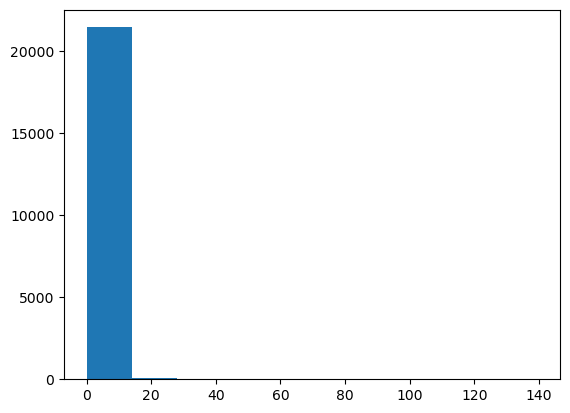

In [3]:
variable = 'ice_number_L'

a_time = sliced_domain.sel(time='2022-07-30T18:00:00.000000000')
#plt.hist(
#        a_time[variable].values.flatten(),
#        bins=bin_edges,
#        facecolor='none',
#        edgecolor='b')
plt.hist(a_time[variable].values.flatten())

In [11]:

variable = 'snow_number_L'

x_max = sliced_domain[variable].max().values
bin_width = 100
bin_edges = np.arange(0, x_max, bin_width)
y_max = 1e5
#max_conc = a_time[variable].max().values
time_list = sliced_domain["time"].values
log_x = True

# saving logic
conc_save_folder = '/home/users/esree/shes_a_model/dcmex_plotting/plot_saving/conc_hist/'
specif_save_folder = f'{conc_save_folder}{a_date}_{a_experiment}'
if not os.path.exists(specif_save_folder):
    os.makedirs(specif_save_folder)
saving_location = specif_save_folder+'/'

# loop through each time
for t in time_list:
    a_time = sliced_domain.sel(time=t)

    plt.figure(figsize=(6, 5))
    plt.hist(
        a_time[variable].values.flatten(),
        bins=bin_edges,
        facecolor='none',
        edgecolor='b')

    plt.xlabel(f'domain {variable}')
    plt.ylabel('Frequency')
    plt.yscale('log')
    if log_x:
        plt.xscale('log')
    plt.ylim(0, y_max)
    plt.xlim(0, x_max)
    plt.text(
        0.95, 0.95,                # x, y in axes coordinates
        f'{pd.to_datetime(str(t)).strftime("%H:%M:%S")}',
        transform=plt.gca().transAxes,
        ha='right',                # horizontal alignment
        va='top',                  # vertical alignment
        fontsize=12)
    
    plt.tight_layout()
    save_name = f"{pd.to_datetime(str(t)).strftime('%y%m%d_%H%M%S')}_{variable}"
    non_time_save_name = f"_{variable}"
    if log_x:
        save_name += '_logx'
        non_time_save_name += '_logx'
    
    plt.savefig(saving_location+save_name)#, bbox_inches='tight')
    plt.close()


/tmp/ipykernel_3036871/3606367986.py:34: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, y_max)
/tmp/ipykernel_3036871/3606367986.py:35: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, x_max)


In [12]:
### make gif - but also only pull images that have just been made
images_loc = saving_location+f'*{non_time_save_name}.png'
image_list = glob(images_loc)
image_list.sort()

frames = []
for i in range(len(image_list)):
    image = imageio.v2.imread(image_list[i])
    frames.append(image)

gif_save_name = f'{a_date}_{a_experiment}_{variable}_hist'
if log_x:
    gif_save_name += '_logx'

imageio.mimsave(saving_location+f'{gif_save_name}.gif', frames, fps=5)

for image in image_list:
    os.remove(image)


In [8]:
image_list

[]

/tmp/ipykernel_3160107/1785900501.py:17: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, y_max)


Text(0.95, 0.95, '18:00:00')

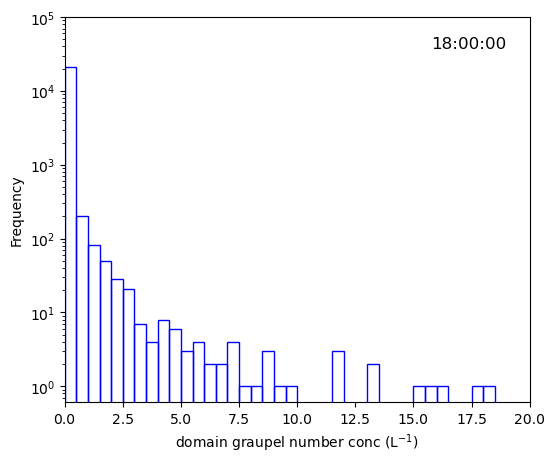

In [ ]:
t ='2022-07-30T18:00:00.000000000'

a_time = sliced_domain.sel(time=t)
plt.figure(figsize=(6, 5))

plt.hist(
    a_time['graupel_number_L'].values.flatten(),
    bins=bin_edges,
    facecolor='none',
    edgecolor='b')

plt.xlabel('domain graupel number conc (L$^{-1}$)')
plt.ylabel('Frequency')
plt.yscale('log')
#plt.xscale('log')
plt.ylim(0, y_max)
plt.xlim(0, x_max)
plt.text(
    0.95, 0.95,                # x, y in axes coordinates
    f'{pd.to_datetime(str(t)).strftime("%H:%M:%S")}',
    transform=plt.gca().transAxes,
    ha='right',                # horizontal alignment
    va='top',                  # vertical alignment
    fontsize=12)